In [65]:
import vertexai
import pandas as pd
import os
import mimetypes
from IPython.display import Image, display
from vertexai.generative_models import GenerativeModel, ChatSession, HarmCategory, HarmBlockThreshold
import json

In [66]:
PROJECT_ID = "spring-2026-lifejacket"
REGION = "us-central1"
vertexai.init(project=PROJECT_ID, location=REGION)

In [67]:
generation_config = {
    "temperature": 0.2,
    "top_p": 0.8,
    "top_k": 40,
    "max_output_tokens": 4096,
}

cv_model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

/opt/conda/lib/python3.10/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


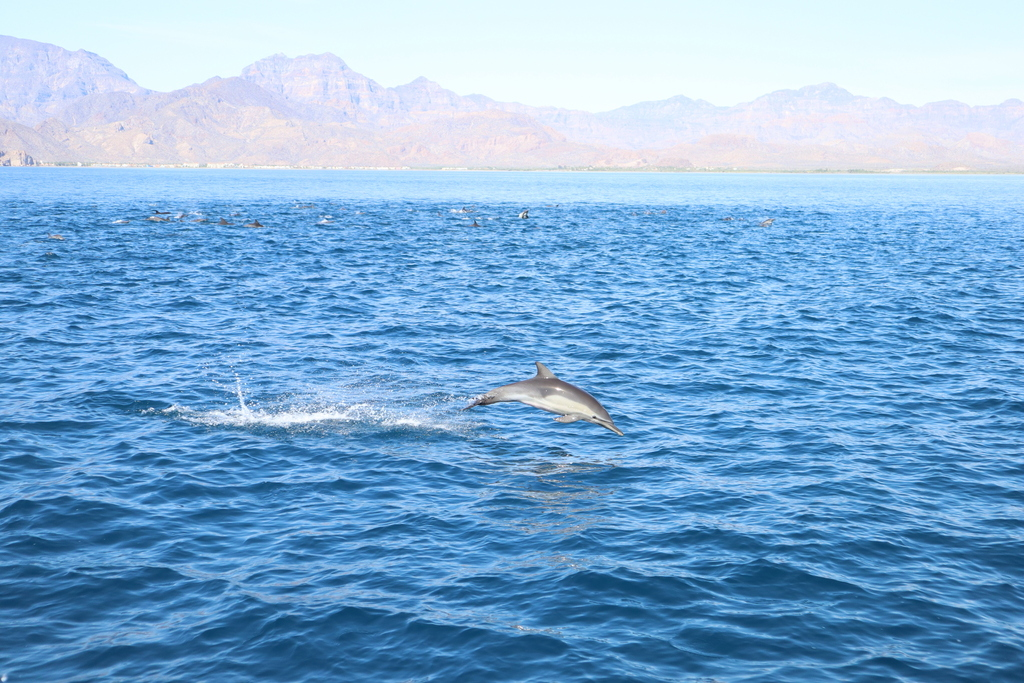

In [80]:
#real CV input
IMAGE_FOLDER = "Gemini Confidence Testing/animal_dataset_images"
METADATA_CSV = "Gemini Confidence Testing/dataset_metadata.csv"

metadata_df = pd.read_csv(METADATA_CSV)

IMAGE_INDEX = 100
sample_row = metadata_df.iloc[IMAGE_INDEX]

image_filename = sample_row["image_filename"]
image_path = os.path.join(IMAGE_FOLDER, image_filename)

display(Image(filename=image_path, width=350))

In [81]:
def extract_json_from_text(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```json", "", text)
        text = re.sub(r"^```", "", text)
        text = re.sub(r"```$", "", text)
        text = text.strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("No JSON object found in Gemini response.")

    return json.loads(text[start:end + 1])


def generate_cv_output_from_image(model, image_path):
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "image/jpeg"

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_part = Part.from_data(
        data=image_bytes,
        mime_type=mime_type
    )

    prompt = """
You are a computer vision model for a sea mammal rescue dispatch system.

Analyze the provided animal image and return ONLY valid JSON.

Your task:
1. Identify the top 3 most likely sea mammal species.
2. Give a confidence score for each species between 0 and 1.
3. Detect whether there may be a visible wound.
4. Detect whether visible blood appears in the image.
5. Determine whether the image is clear enough for species and injury assessment.
6. Briefly explain the image clarity reason.

Important rules:
- Return ONLY JSON.
- Do not include markdown.
- Do not include explanation outside JSON.
- Confidence scores should sum approximately to 1.
- If the image is unclear, still provide best guesses but lower the confidence.
- Do not invent injury details that are not visible.
- If wound or blood cannot be determined, use false.
- If species cannot be determined, still provide the best 3 guesses with low confidence.

Return JSON in exactly this structure:

{
  "cv_species_top3": [
    {
      "species": "species name",
      "confidence": 0.0
    },
    {
      "species": "species name",
      "confidence": 0.0
    },
    {
      "species": "species name",
      "confidence": 0.0
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "brief reason"
  }
}
"""

    response = model.generate_content([prompt, image_part])
    return extract_json_from_text(response.text)


cv_output = generate_cv_output_from_image(cv_model, image_path)

print("CV output generated from real image:")
print(json.dumps(cv_output, indent=2))

CV output generated from real image:
{
  "cv_species_top3": [
    {
      "species": "Common Dolphin",
      "confidence": 0.9
    },
    {
      "species": "Striped Dolphin",
      "confidence": 0.08
    },
    {
      "species": "Bottlenose Dolphin",
      "confidence": 0.02
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "The main dolphin is sharp, well-lit, and in focus, allowing for clear observation of its features."
  }
}


In [82]:
def extract_json_from_text(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```json", "", text)
        text = re.sub(r"^```", "", text)
        text = re.sub(r"```$", "", text)
        text = text.strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("No JSON object found in Gemini response.")

    return json.loads(text[start:end + 1])


def generate_cv_output_from_image(model, image_path):
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "image/jpeg"

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_part = Part.from_data(
        data=image_bytes,
        mime_type=mime_type
    )

    prompt = """
You are a computer vision model for a sea mammal rescue dispatch system.

Analyze the provided animal image and return ONLY valid JSON.

Your task:
1. Identify the top 3 most likely sea mammal species.
2. Give a confidence score for each species between 0 and 1.
3. Detect whether there may be a visible wound.
4. Detect whether visible blood appears in the image.
5. Determine whether the image is clear enough for species and injury assessment.
6. Briefly explain the image clarity reason.

Important rules:
- Return ONLY JSON.
- Do not include markdown.
- Do not include explanation outside JSON.
- Confidence scores should sum approximately to 1.
- If the image is unclear, still provide best guesses but lower the confidence.
- Do not invent injury details that are not visible.
- If wound or blood cannot be determined, use false.
- If species cannot be determined, still provide the best 3 guesses with low confidence.

Return JSON in exactly this structure:

{
  "cv_species_top3": [
    {
      "species": "species name",
      "confidence": 0.0
    },
    {
      "species": "species name",
      "confidence": 0.0
    },
    {
      "species": "species name",
      "confidence": 0.0
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "brief reason"
  }
}
"""

    response = model.generate_content([prompt, image_part])
    return extract_json_from_text(response.text)


cv_output = generate_cv_output_from_image(cv_model, image_path)

print("CV output generated from real image:")
print(json.dumps(cv_output, indent=2))

CV output generated from real image:
{
  "cv_species_top3": [
    {
      "species": "Common Dolphin",
      "confidence": 0.9
    },
    {
      "species": "Spinner Dolphin",
      "confidence": 0.08
    },
    {
      "species": "Bottlenose Dolphin",
      "confidence": 0.02
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "The main subject (dolphin) is in focus and well-lit, allowing for clear species identification and injury assessment."
  }
}


In [83]:
def extract_json_from_text(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```json", "", text)
        text = re.sub(r"^```", "", text)
        text = re.sub(r"```$", "", text)
        text = text.strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("No JSON object found in Gemini response.")

    return json.loads(text[start:end + 1])


def generate_cv_output_from_image(model, image_path):
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "image/jpeg"

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_part = Part.from_data(
        data=image_bytes,
        mime_type=mime_type
    )

    prompt = """
You are a computer vision model for a sea mammal rescue dispatch system.

Analyze the provided animal image and return ONLY valid JSON.

Your task:
1. Identify the top 3 most likely sea mammal species.
2. Give a confidence score for each species between 0 and 1.
3. Detect whether there may be a visible wound.
4. Detect whether visible blood appears in the image.
5. Determine whether the image is clear enough for species and injury assessment.
6. Briefly explain the image clarity reason.

Important rules:
- Return ONLY JSON.
- Do not include markdown.
- Do not include explanation outside JSON.
- Confidence scores should sum approximately to 1.
- If the image is unclear, still provide best guesses but lower the confidence.
- Do not invent injury details that are not visible.
- If wound or blood cannot be determined, use false.
- If species cannot be determined, still provide the best 3 guesses with low confidence.

Return JSON in exactly this structure:

{
  "cv_species_top3": [
    {
      "species": "species name",
      "confidence": 0.0
    },
    {
      "species": "species name",
      "confidence": 0.0
    },
    {
      "species": "species name",
      "confidence": 0.0
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "brief reason"
  }
}
"""

    response = model.generate_content([prompt, image_part])
    return extract_json_from_text(response.text)


cv_output = generate_cv_output_from_image(cv_model, image_path)

print("CV output generated from real image:")
print(json.dumps(cv_output, indent=2))

CV output generated from real image:
{
  "cv_species_top3": [
    {
      "species": "Short-beaked Common Dolphin",
      "confidence": 0.95
    },
    {
      "species": "Long-beaked Common Dolphin",
      "confidence": 0.04
    },
    {
      "species": "Striped Dolphin",
      "confidence": 0.01
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "The main subject (dolphin) is in sharp focus, well-lit, and clearly visible, allowing for detailed species and injury assessment."
  }
}


In [84]:
# real location from dataset

raw_place_name = sample_row.get("description", "")

if pd.isna(raw_place_name):
    raw_place_name = ""

location_output = {
    "location_available": True,
    "location_source": "dataset_metadata.csv",
    "latitude": float(sample_row["latitude"]),
    "longitude": float(sample_row["longitude"]),
    "place_name": raw_place_name,
    "image_filename": image_filename,
    "image_date": str(sample_row.get("date", "")),
    "image_time": str(sample_row.get("time", ""))
}

print(json.dumps(location_output, indent=2))

{
  "location_available": true,
  "location_source": "dataset_metadata.csv",
  "latitude": 25.9254908835,
  "longitude": -111.2815182709,
  "place_name": "",
  "image_filename": "361455440.jpg",
  "image_date": "2026-05-14",
  "image_time": "9"
}


In [73]:
#Five fixed input Question
fixed_question_options = {
    "reported_size": {
        "question": "How large is the animal?",
        "options": {
            "A": "smaller_than_dog",
            "B": "about_dog_size",
            "C": "about_human_size",
            "D": "larger_than_human",
            "E": "not_sure"
        }
    },
    "reported_color": {
        "question": "What is the main color of the animal?",
        "options": {
            "A": "light_gray",
            "B": "dark_gray",
            "C": "brown",
            "D": "black",
            "E": "white_or_pale",
            "F": "not_sure"
        }
    },
    "reported_mobility": {
        "question": "Is the animal moving?",
        "options": {
            "A": "moving_normally",
            "B": "moving_slowly_or_weakly",
            "C": "not_moving_but_appears_alive",
            "D": "not_moving_may_be_dead",
            "E": "not_sure"
        }
    },
    "reported_visible_wound": {
        "question": "Do you see any visible wound?",
        "options": {
            "A": True,
            "B": False,
            "C": "not_sure"
        }
    },
    "reported_bleeding": {
        "question": "Do you see any bleeding?",
        "options": {
            "A": True,
            "B": False,
            "C": "not_sure"
        }
    }
}

In [74]:
def ask_fixed_questions():
    user_answers = {}

    for field_name, q in fixed_question_options.items():
        print("\n" + q["question"])
        for key, value in q["options"].items():
            print(f"{key}. {value}")

        user_choice = input("Choose one option: ").strip().upper()

        while user_choice not in q["options"]:
            print("Invalid choice. Please choose again.")
            user_choice = input("Choose one option: ").strip().upper()

        user_answers[field_name] = q["options"][user_choice]

    return user_answers


user_fixed_answers = ask_fixed_questions()

print(user_fixed_answers)


How large is the animal?
A. smaller_than_dog
B. about_dog_size
C. about_human_size
D. larger_than_human
E. not_sure


Choose one option:  A



What is the main color of the animal?
A. light_gray
B. dark_gray
C. brown
D. black
E. white_or_pale
F. not_sure


Choose one option:  F



Is the animal moving?
A. moving_normally
B. moving_slowly_or_weakly
C. not_moving_but_appears_alive
D. not_moving_may_be_dead
E. not_sure


...


Do you see any visible wound?
A. True
B. False
C. not_sure


Choose one option:  B



Do you see any bleeding?
A. True
B. False
C. not_sure


Choose one option:  A


{'reported_size': 'smaller_than_dog', 'reported_color': 'not_sure', 'reported_mobility': 'moving_normally', 'reported_visible_wound': False, 'reported_bleeding': True}


In [75]:
# Integrate three separate inputs into one structured package for Gemini

incident_package = {

    "cv_output": cv_output,

    "location_output": location_output,

    "user_fixed_answers": user_fixed_answers

}

print(json.dumps(incident_package, indent=2))

{
  "cv_output": {
    "cv_species_top3": [
      {
        "species": "Common Dolphin",
        "confidence": 0.001
      },
      {
        "species": "Harbor Seal",
        "confidence": 0.001
      },
      {
        "species": "Manatee",
        "confidence": 0.001
      }
    ],
    "cv_observed_features": {
      "possible_wound": false,
      "visible_blood": false,
      "image_clear": false,
      "image_clarity_reason": "No sea mammals are present in the image for assessment."
    }
  },
  "location_output": {
    "location_available": true,
    "location_source": "dataset_metadata.csv",
    "latitude": 39.5333716667,
    "longitude": -83.4209133333,
    "place_name": "",
    "image_filename": "362741764.jpg",
    "image_date": "2026-05-18",
    "image_time": "9"
  },
  "user_fixed_answers": {
    "reported_size": "smaller_than_dog",
    "reported_color": "not_sure",
    "reported_mobility": "moving_normally",
    "reported_visible_wound": false,
    "reported_bleeding": tru

## LLM

In [76]:
def build_llm_prompt(incident_package, followup_history=None):
    if followup_history is None:
        followup_history = []

    prompt = f"""
You are Agent 1: Marine Mammal Incident Intake and Verification Agent.

You receive one structured input package called incident_package.
This package contains three separate inputs:
1. cv_output from a teammate's computer vision module
2. location_output from a mocked location service
3. user_fixed_answers from fixed multiple-choice intake questions

Important:
- The CV module has already analyzed the photo.
- Do not claim that you directly inspected the image.
- Use only cv_output, location_output, user_fixed_answers, and followup_history.
- Your first task is species and injury identification.
- For species identification, estimate the most likely species and confidence.
- If species confidence is 0.90 or above, set species_verification_status to "verified" and llm_needs_followup to false.
- If species confidence is below 0.90, ask exactly one targeted follow-up question.
- Do not ask unlimited questions.
- Injury confidence does not need to be above 0.90. If injury information is uncertain, record it as unknown or low confidence.
- Always give safe public guidance.
- Do not tell the reporter to touch, feed, move, pour water on, or approach the animal.

Follow-up policy:
Choose exactly one llm_followup_type when follow-up is needed:
1. "species_disambiguation" if species needs clarification, such as sea lion vs seal.
2. "cv_user_conflict" if CV output and user answers conflict.
3. "request_new_photo" if the image or current evidence is too unclear and another photo would help.
4. "injury_clarification" if injury risk needs clarification, such as bleeding, wound, or entanglement.
5. "stop_uncertain" if enough follow-up has already been attempted but confidence is still below 0.90.

Follow-up question rules:
- Ask exactly one follow-up question at a time.
- Each follow-up question must ask only one thing.
- Do not combine multiple traits in one question.
- Do not ask the same or semantically similar follow-up question twice.
- If a follow-up question has already been answered in followup_history, use that answer to update your confidence.
- If the answer is unclear, ask a different question or request a new photo.
- Do not keep asking follow-up questions indefinitely.

Species disambiguation rules:
- If followup_history says the animal has visible ear flaps, this strongly supports California sea lion over harbor seal.
- If followup_history says the animal has only small ear holes and no visible ear flaps, this supports harbor seal over California sea lion.
- If followup_history says the animal can rotate its hind flippers forward to move on land, this supports sea lion.
- If followup_history says the animal crawls on its belly and cannot rotate hind flippers forward, this supports true seals such as harbor seal.
- If the follow-up answer clearly supports the top species, increase species confidence when appropriate.
- If the follow-up answer contradicts the CV top species, lower confidence for the CV top species and consider another top-3 species.

CV-user conflict rules:
- If CV output and user_fixed_answers conflict, set llm_followup_type to "cv_user_conflict" when clarification would materially improve confidence.
- Do not overwrite user answers. Record the conflict in llm_followup_reason or llm_injury_summary.
- If user_fixed_answers report bleeding as true but cv_visible_blood is false, set llm_bleeding_present based on the combined evidence and mention the discrepancy.
- If user_fixed_answers report visible wound as true, set llm_wound_present to true unless follow-up evidence clearly contradicts it.

Image quality / new photo rules:
- If evidence remains insufficient after one species_disambiguation question, prefer llm_followup_type = "request_new_photo".
- When requesting a new photo, ask the user to upload another photo from a safe distance without approaching the animal.
- If requesting a new photo, set new_photo_requested to true and species_verification_status to "new_photo_requested".

Stop uncertain rules:
- If followup_history already contains 2 or more entries and species confidence is still below 0.90, do not ask more questions.
- Set llm_needs_followup to false.
- Set llm_followup_type to "stop_uncertain".
- Set species_verification_status to "uncertain_needs_review".
- Keep the best current species estimate and confidence.
- Do not artificially raise confidence to 0.90 if the evidence is insufficient.

Allowed species_verification_status values:
- "verified"
- "needs_followup"
- "new_photo_requested"
- "uncertain_needs_review"

Follow-up history:
{json.dumps(followup_history, indent=2)}

Input incident_package:
{json.dumps(incident_package, indent=2)}

Return JSON only. Do not include markdown.

Required JSON schema:
{{
  "llm_likely_species": "",
  "llm_species_confidence": 0.0,
  "species_verification_status": "",
  "llm_needs_followup": true,
  "llm_followup_type": "",
  "llm_followup_reason": "",
  "llm_followup_question": "",
  "new_photo_requested": false,

  "llm_injury_present": false,
  "llm_injury_confidence": 0.0,
  "llm_wound_present": false,
  "llm_bleeding_present": false,
  "llm_entanglement_present": false,
  "llm_swelling_present": false,
  "llm_abnormal_posture_present": false,
  "llm_respiratory_distress_present": false,
  "llm_unresponsive_present": false,
  "llm_mobility_concern": "",
  "llm_injury_summary": "",

  "guidance_message": ""
}}
"""
    return prompt

In [77]:
def extract_json_from_response(text):
    text = text.strip()

    if text.startswith("```json"):
        text = text.replace("```json", "").replace("```", "").strip()
    elif text.startswith("```"):
        text = text.replace("```", "").strip()

    return json.loads(text)


def call_gemini_for_assessment(model, incident_package, followup_history=None):
    prompt = build_llm_prompt(incident_package, followup_history)

    print("\nSending incident package to Gemini...")

    response = model.generate_content(prompt)

    response_text = response.text
    llm_output = extract_json_from_response(response_text)

    return llm_output

**If species confidence < 90%，Start chatbox follow-up**

In [78]:
def run_species_followup_chat(model, incident_package, max_followups=2):
    followup_history = []
    new_photo_requested_once = False

    for i in range(max_followups + 2):
        print(f"\nLLM assessment round {i + 1}")

        llm_output = call_gemini_for_assessment(
            model=model,
            incident_package=incident_package,
            followup_history=followup_history
        )

        species_confidence = llm_output.get("llm_species_confidence", 0.0)
        likely_species = llm_output.get("llm_likely_species", "")
        needs_followup = llm_output.get("llm_needs_followup", False)
        followup_type = llm_output.get("llm_followup_type", "")
        followup_question = llm_output.get("llm_followup_question", "")
        verification_status = llm_output.get("species_verification_status", "")

        cv_features = incident_package.get("cv_output", {}).get("cv_observed_features", {})
        image_clear = cv_features.get("image_clear", True)
        image_clarity_reason = cv_features.get("image_clarity_reason", "")

        print(f"Likely species: {likely_species}")
        print(f"Species confidence: {species_confidence}")
        print(f"Species verification status: {verification_status}")
        print(f"Follow-up type: {followup_type}")
        print(f"Image clear: {image_clear}")
        print(f"Image clarity reason: {image_clarity_reason}")
        print(f"Injury present: {llm_output.get('llm_injury_present')}")
        print(f"Injury summary: {llm_output.get('llm_injury_summary')}")
        print(f"Guidance: {llm_output.get('guidance_message')}")

        # Case 1: species confidence is high enough
        if species_confidence >= 0.90:
            print("\nSpecies confidence is above 90%. Stop follow-up.")
            return llm_output, followup_history

        # Case 2: species confidence is below 90%, and image is blurry/unclear
        # Ask for a new photo only once before normal follow-up questions.
        if image_clear is False and not new_photo_requested_once:
            print("\nSpecies confidence is below 90% and image is unclear.")
            print("Please submit another photo from a safe distance if possible.")

            new_image_path = input("New image path, or press Enter to skip: ").strip()

            new_photo_requested_once = True

            if new_image_path:
                print("\nGenerating new CV output from the resubmitted image...")

                new_cv_output = generate_cv_output_from_image(
                    model=cv_model,
                    image_path=new_image_path
                )

                incident_package["cv_output"] = new_cv_output

                followup_history.append({
                    "followup_type": "request_new_photo",
                    "question": "Please submit another photo from a safe distance if possible.",
                    "answer": new_image_path
                })

                print("\nNew CV output:")
                print(json.dumps(new_cv_output, indent=2))

                # Continue loop and reassess with updated cv_output
                continue

            else:
                followup_history.append({
                    "followup_type": "request_new_photo",
                    "question": "Please submit another photo from a safe distance if possible.",
                    "answer": "No new photo submitted."
                })

                print("\nNo new photo submitted. Continue with normal follow-up questions.")

        # Case 3: stop uncertain
        if followup_type == "stop_uncertain":
            print("\nSpecies is still uncertain. Stop follow-up and mark for review.")
            return llm_output, followup_history

        # Case 4: LLM says no follow-up needed
        if not needs_followup:
            print("\nNo follow-up needed. Stop follow-up.")
            return llm_output, followup_history

        # Count only actual question follow-ups, not new photo request
        question_followups = [
            item for item in followup_history
            if item.get("followup_type") != "request_new_photo"
        ]

        if len(question_followups) >= max_followups:
            print("\nMax follow-up question limit reached. Stop and save current result as uncertain.")
            llm_output["llm_needs_followup"] = False
            llm_output["llm_followup_type"] = "stop_uncertain"
            llm_output["species_verification_status"] = "uncertain_needs_review"
            return llm_output, followup_history

        # Case 5: normal chatbox follow-up question
        print("\nFollow-up question:")
        print(followup_question)

        user_answer = input("Your answer: ").strip()

        followup_history.append({
            "followup_type": followup_type,
            "question": followup_question,
            "answer": user_answer
        })

    return llm_output, followup_history

In [79]:
generation_config = {
    "temperature": 0.2,
    "top_p": 0.8,
    "top_k": 40,
    "max_output_tokens": 4096,
}

model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

final_llm_output, followup_history = run_species_followup_chat(
    model=model,
    incident_package=incident_package,
    max_followups=2
)

print("\nFinal LLM output:")
print(json.dumps(final_llm_output, indent=2))

print("\nFollow-up history:")
print(json.dumps(followup_history, indent=2))

/opt/conda/lib/python3.10/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()



LLM assessment round 1

Sending incident package to Gemini...
Likely species: Undetermined
Species confidence: 0.0
Species verification status: new_photo_requested
Follow-up type: request_new_photo
Image clear: False
Image clarity reason: No sea mammals are present in the image for assessment.
Injury present: True
Injury summary: The user reported bleeding, but the computer vision module was unable to detect any marine mammal in the provided image to confirm this. The animal was reported to be moving normally.
Guidance: Thank you for your report. We were unable to detect a marine mammal in the provided image. Please upload another photo of the animal from a safe distance, without approaching it. Do not touch, feed, move, or pour water on the animal. Keep people and pets away.

Species confidence is below 90% and image is unclear.
Please submit another photo from a safe distance if possible.


New image path, or press Enter to skip:  



No new photo submitted. Continue with normal follow-up questions.

Follow-up question:
Could you please upload another photo of the animal from a safe distance? This will help us identify the species and assess its condition.


Your answer:  No more picture



LLM assessment round 2

Sending incident package to Gemini...
Likely species: Common Dolphin
Species confidence: 0.001
Species verification status: uncertain_needs_review
Follow-up type: stop_uncertain
Image clear: False
Image clarity reason: No sea mammals are present in the image for assessment.
Injury present: True
Injury summary: The reporter indicated bleeding, but the provided image does not contain a marine mammal, so this cannot be visually confirmed. The animal was reported to be moving normally. Due to the lack of visual evidence, injury assessment is highly uncertain.
Guidance: Thank you for your report. Based on the information provided, we cannot confirm the species or any injuries from the image, as it did not contain a marine mammal. The reporter indicated the animal was bleeding and moving normally. Please remember to always maintain a safe distance from marine mammals, do not approach, touch, feed, or pour water on them. If you observe the animal again and it appears 

**CSV output**

In [39]:
import pandas as pd
import uuid
from datetime import datetime

In [42]:
def build_database_row(incident_package, final_llm_output, followup_history):
    cv_output = incident_package["cv_output"]
    location_output = incident_package["location_output"]
    user_answers = incident_package["user_fixed_answers"]

    cv_species_top3 = cv_output.get("cv_species_top3", [])
    cv_features = cv_output.get("cv_observed_features", {})

    def get_species_field(index, field):
        if len(cv_species_top3) > index:
            return cv_species_top3[index].get(field)
        return None

    row = {
        "incident_id": f"INC_{uuid.uuid4().hex[:8]}",
        "photo_id": location_output.get("image_filename", f"PHOTO_{uuid.uuid4().hex[:8]}"),
        "animal_id": f"ANIMAL_{uuid.uuid4().hex[:8]}",
        "report_timestamp": datetime.now().isoformat(timespec="seconds"),

        # real image metadata
        "image_filename": location_output.get("image_filename"),
        "image_date": location_output.get("image_date"),
        "image_time": location_output.get("image_time"),

        # real location metadata
        "latitude": location_output.get("latitude"),
        "longitude": location_output.get("longitude"),
        "place_name": location_output.get("place_name"),
        "location_source": location_output.get("location_source"),

        # CV species output
        "cv_top1_species": get_species_field(0, "species"),
        "cv_top1_confidence": get_species_field(0, "confidence"),
        "cv_top2_species": get_species_field(1, "species"),
        "cv_top2_confidence": get_species_field(1, "confidence"),
        "cv_top3_species": get_species_field(2, "species"),
        "cv_top3_confidence": get_species_field(2, "confidence"),

        # CV observed features
        "cv_possible_wound": cv_features.get("possible_wound"),
        "cv_visible_blood": cv_features.get("visible_blood"),
        "cv_image_clear": cv_features.get("image_clear"),
        "cv_image_clarity_reason": cv_features.get("image_clarity_reason"),

        # user fixed answers
        "reported_size": user_answers.get("reported_size"),
        "reported_color": user_answers.get("reported_color"),
        "reported_mobility": user_answers.get("reported_mobility"),
        "reported_visible_wound": user_answers.get("reported_visible_wound"),
        "reported_bleeding": user_answers.get("reported_bleeding"),

        # LLM species verification output
        "llm_likely_species": final_llm_output.get("llm_likely_species"),
        "llm_species_confidence": final_llm_output.get("llm_species_confidence"),
        "species_verification_status": final_llm_output.get("species_verification_status"),
        "llm_needs_followup": final_llm_output.get("llm_needs_followup"),
        "llm_followup_type": final_llm_output.get("llm_followup_type"),
        "llm_followup_reason": final_llm_output.get("llm_followup_reason"),
        "llm_followup_question": final_llm_output.get("llm_followup_question"),
        "new_photo_requested": final_llm_output.get("new_photo_requested"),

        # LLM injury output
        "llm_injury_present": final_llm_output.get("llm_injury_present"),
        "llm_injury_confidence": final_llm_output.get("llm_injury_confidence"),
        "llm_wound_present": final_llm_output.get("llm_wound_present"),
        "llm_bleeding_present": final_llm_output.get("llm_bleeding_present"),
        "llm_entanglement_present": final_llm_output.get("llm_entanglement_present"),
        "llm_swelling_present": final_llm_output.get("llm_swelling_present"),
        "llm_abnormal_posture_present": final_llm_output.get("llm_abnormal_posture_present"),
        "llm_respiratory_distress_present": final_llm_output.get("llm_respiratory_distress_present"),
        "llm_unresponsive_present": final_llm_output.get("llm_unresponsive_present"),
        "llm_mobility_concern": final_llm_output.get("llm_mobility_concern"),
        "llm_injury_summary": final_llm_output.get("llm_injury_summary"),

        # public guidance
        "guidance_message": final_llm_output.get("guidance_message"),

        # full traceability
        "followup_count": len(followup_history),
        "followup_history_json": json.dumps(followup_history, ensure_ascii=False),
        "incident_package_json": json.dumps(incident_package, ensure_ascii=False, default=str),
        "final_llm_output_json": json.dumps(final_llm_output, ensure_ascii=False)
    }

    return row

In [43]:
def save_database_row_to_csv(database_row, csv_path="agent1_incident_database.csv"):
    new_df = pd.DataFrame([database_row])

    try:
        existing_df = pd.read_csv(csv_path)
        final_df = pd.concat([existing_df, new_df], ignore_index=True)
    except FileNotFoundError:
        final_df = new_df

    final_df.to_csv(csv_path, index=False)
    return final_df

In [44]:
database_row = build_database_row(
    incident_package=incident_package,
    final_llm_output=final_llm_output,
    followup_history=followup_history
)

database_df = save_database_row_to_csv(
    database_row=database_row,
    csv_path="agent1_incident_database.csv"
)

print("\nSaved one incident row to CSV.")
print(database_df.tail(1))


Saved one incident row to CSV.
    incident_id        photo_id        animal_id     report_timestamp  \
0  INC_b0fe9663  PHOTO_7beeb559  ANIMAL_a684d074  2026-05-11T22:36:40   

   latitude  longitude               place_name location_source  \
0   34.4208  -119.6982  Santa Barbara Beach, CA   mock_location   

       cv_top1_species  cv_top1_confidence  ... llm_abnormal_posture_present  \
0  California sea lion                0.72  ...                        False   

   llm_respiratory_distress_present llm_unresponsive_present  \
0                             False                    False   

   llm_mobility_concern                                 llm_injury_summary  \
0                  none  A wound is reported by both computer vision an...   

                                    guidance_message followup_count  \
0  Thank you for reporting this incident at Santa...              1   

                               followup_history_json  \
0  [{"question": "Does the animal have v